In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

**Transform PIL to Tensor**

In [74]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

**Datasets**

In [75]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


**Dataloaders**

In [76]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
val_loader = DataLoader(test_set, batch_size=64, shuffle=False)

## **Models**

In [77]:
class CnnModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CnnModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## **Training**

In [78]:
model = CnnModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [79]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [80]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

In [81]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [89]:
def learning_curves(history, test_loss_final):

    plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    plt.axhline(test_loss_final, label='Final Test Loss', linestyle='--', color='red', linewidth=2)
    plt.title('CNN Model Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()


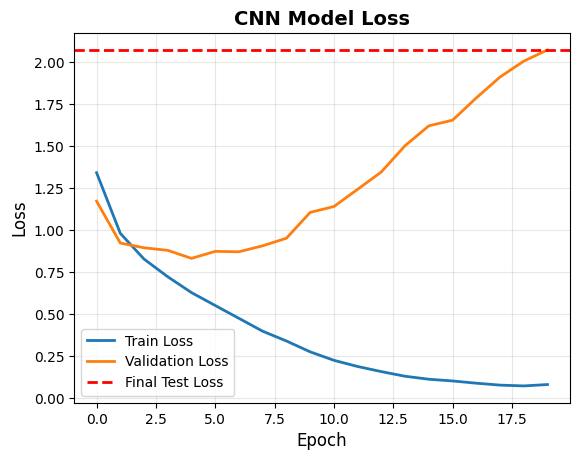

In [90]:
# Train the model
history = train(model, train_loader, val_loader, criterion, optimizer, _num_epochs=20)

# Evaluate
test_loss, test_acc = test(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# learning curves
learning_curves(history, test_loss)
